# Natural Language Processing

This notebook converts translated open-ended responses into theme summaries, NLP tags, segment fallback tags, and rule-based recommendation features. Runtime constants are loaded from `ml/config/config.json` under the `nlp` section.

In [1]:
# LOAD CONFIG AND NLP-READY DATASET

from pathlib import Path
import json
import sys

# Make imports work from either project/ml or project/ml/notebook.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    src_dir = candidate / "src"
    config_file = candidate / "config" / "config.json"
    if src_dir.exists() and config_file.exists():
        ML_ROOT = candidate.resolve()
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise FileNotFoundError("Could not find the ml project root containing config/config.json and src/.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from blended_learning.config.settings import settings
from blended_learning.utils.notebook import resolve_project_path
from blended_learning.nlp.rules import (
    clean_basic_text,
    normalize_text_for_matching,
    detect_themes,
    themes_to_tags,
    get_segment_default_tags,
    create_final_recommendation_tags,
    build_rule_based_recommendations,
)

nlp_cfg = settings.nlp

input_path = resolve_project_path(nlp_cfg["io"]["input_path"], settings.root)
read_options = nlp_cfg["io"].get("read_csv_options", {})

if not input_path.exists():
    raise FileNotFoundError(
        f"NLP input file not found: {input_path}\n"
        "Run 06-translation_preprocessing.ipynb first, or update nlp.io.input_path in config.json."
    )
df = pd.read_csv(input_path, **read_options)
print(f"NLP-ready dataset loaded: {df.shape}")
display(df.head(nlp_cfg.get("display", {}).get("preview_rows", 10)))


NLP-ready dataset loaded: (570, 9)


,student_id,open_strengths,open_challenges_suggestions,student_segment,student_segment_label,open_strengths_lang,open_challenges_suggestions_lang,open_strengths_en,open_challenges_suggestions_en
0,e20210686,Nothing,Nothing,1,Moderately Engaged (Passive) Learners,en,en,Nothing,Nothing
1,e20241146,"Very good, excellent","No big challenge, i’m the best",2,Highly Engaged (Active) Learners,en,en,"Very good, excellent","No big challenge, i’m the best"
2,e20240609,Will try hard,Lack of self-discipline,2,Highly Engaged (Active) Learners,en,en,Will try hard,Lack of self-discipline
3,e20240542,getting more experience,Discipline on daily studying,1,Moderately Engaged (Passive) Learners,en,en,getting more experience,Discipline on daily studying
4,e20220287,Student could retrieve the lesson once they wa...,Add Ai assistance,1,Moderately Engaged (Passive) Learners,en,en,Student could retrieve the lesson once they wa...,Add Ai assistance
5,e20210180,Innovate yourself with the technology world,Lack of resources and misinformation,1,Moderately Engaged (Passive) Learners,en,en,Innovate yourself with the technology world,Lack of resources and misinformation
6,e20241245,Blended learning has many positive aspects. It...,The biggest challenges of blended learning are...,1,Moderately Engaged (Passive) Learners,en,en,Blended learning has many positive aspects. It...,The biggest challenges of blended learning are...
7,e20221090,Give a chance for students who prefer both onl...,"Internet issues, technical problems, lack of i...",2,Highly Engaged (Active) Learners,en,en,Give a chance for students who prefer both onl...,"Internet issues, technical problems, lack of i..."
8,e20250089,Give me time to do my stuff,Probably the internet connection,1,Moderately Engaged (Passive) Learners,en,en,Give me time to do my stuff,Probably the internet connection
9,e20240950,Agree,Agree,2,Highly Engaged (Active) Learners,en,en,Agree,Agree


In [2]:
# CONFIG SHORTCUTS

text_cols = nlp_cfg["columns"]["text"]
cluster_col = nlp_cfg["columns"]["cluster"]
cluster_label_col = nlp_cfg["columns"]["cluster_label"]

tfidf_cfg = nlp_cfg["tfidf"]
tagging_cfg = nlp_cfg["tagging"]
visual_cfg = nlp_cfg["visualisation"]

strength_theme_map = getattr(settings, nlp_cfg["theme_maps"]["strength_config_key"])
challenge_theme_map = getattr(settings, nlp_cfg["theme_maps"]["challenge_config_key"])
theme_to_recommendation_map = getattr(settings, nlp_cfg["theme_maps"]["theme_to_recommendation_config_key"])

print("Configured text columns:")
print(json.dumps(text_cols, indent=2))

Configured text columns:
{
  "strength_source": "open_strengths_en",
  "challenge_source": "open_challenges_suggestions_en",
  "strength_clean": "open_strengths_clean",
  "challenge_clean": "open_challenges_clean"
}


In [3]:
# BASIC TEXT CLEANING

cleaning_cfg = nlp_cfg["text_cleaning"]
df[text_cols["strength_clean"]] = df[text_cols["strength_source"]].apply(lambda x: clean_basic_text(x, cleaning_cfg))
df[text_cols["challenge_clean"]] = df[text_cols["challenge_source"]].apply(lambda x: clean_basic_text(x, cleaning_cfg))

display(df[[text_cols["strength_source"], text_cols["strength_clean"], text_cols["challenge_source"], text_cols["challenge_clean"]]].head(nlp_cfg.get("display", {}).get("preview_rows", 10)))


,open_strengths_en,open_strengths_clean,open_challenges_suggestions_en,open_challenges_clean
0,Nothing,nothing,Nothing,nothing
1,"Very good, excellent",very good excellent,"No big challenge, i’m the best",no big challenge i m the best
2,Will try hard,will try hard,Lack of self-discipline,lack of self discipline
3,getting more experience,getting more experience,Discipline on daily studying,discipline on daily studying
4,Student could retrieve the lesson once they wa...,student could retrieve the lesson once they wa...,Add Ai assistance,add ai assistance
5,Innovate yourself with the technology world,innovate yourself with the technology world,Lack of resources and misinformation,lack of resources and misinformation
6,Blended learning has many positive aspects. It...,blended_learning has many positive aspects it ...,The biggest challenges of blended learning are...,the biggest challenges of blended_learning are...
7,Give a chance for students who prefer both onl...,give a chance for students who prefer both onl...,"Internet issues, technical problems, lack of i...",internet issues technical problems lack of int...
8,Give me time to do my stuff,give me time to do my stuff,Probably the internet connection,probably the internet_connection
9,Agree,agree,Agree,agree


## Custom stopwords and TF-IDF keyword extraction

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer

stopword_cfg = nlp_cfg["stopwords"]
custom_stopwords = set()

if stopword_cfg.get("include_sklearn_english", True):
    custom_stopwords.update(ENGLISH_STOP_WORDS)

custom_key = stopword_cfg.get("custom_stopwords_config_key")
if custom_key:
    custom_stopwords.update(getattr(settings, custom_key))

if stopword_cfg.get("expand_multiword_stopwords", True):
    analyzer = CountVectorizer().build_analyzer()
    expanded_stopwords = set(custom_stopwords)
    for word in custom_stopwords:
        expanded_stopwords.update(analyzer(word))
    custom_stopwords = expanded_stopwords

custom_stopwords = sorted(custom_stopwords)
print(f"Stopwords loaded: {len(custom_stopwords)}")

Stopwords loaded: 491


In [5]:
def get_top_tfidf_keywords(df, text_col, top_n=None, ngram_range=None, min_df=None, max_df=None):
    top_n = top_n or tfidf_cfg["top_n_keywords"]
    ngram_range = tuple(ngram_range or tfidf_cfg["ngram_range"])
    min_df = min_df if min_df is not None else tfidf_cfg["min_df"]
    max_df = max_df if max_df is not None else tfidf_cfg["max_df"]

    texts = df[text_col].fillna("").astype(str)
    texts = texts[texts.str.strip() != ""]
    if texts.empty:
        return pd.DataFrame(columns=["keyword", "tfidf_score"])

    vectorizer = TfidfVectorizer(stop_words=list(custom_stopwords), ngram_range=ngram_range, min_df=min_df, max_df=max_df)
    try:
        tfidf_matrix = vectorizer.fit_transform(texts)
    except ValueError as exc:
        print(f"Skipping TF-IDF for {text_col}: {exc}")
        return pd.DataFrame(columns=["keyword", "tfidf_score"])

    keyword_df = pd.DataFrame({"keyword": vectorizer.get_feature_names_out(), "tfidf_score": tfidf_matrix.sum(axis=0).A1})
    keyword_df["keyword"] = keyword_df["keyword"].str.replace("_", " ", regex=False)
    return keyword_df.sort_values("tfidf_score", ascending=False).head(top_n).reset_index(drop=True)

## Bigram TF-IDF keyword extraction

In [6]:
strengths_keywords = get_top_tfidf_keywords(df, text_cols["strength_clean"])
challenges_keywords = get_top_tfidf_keywords(df, text_cols["challenge_clean"])

print("Top TF-IDF keywords and phrases: strengths")
display(strengths_keywords)
print("Top TF-IDF keywords and phrases: challenges/suggestions")
display(challenges_keywords)

Top TF-IDF keywords and phrases: strengths


,keyword,tfidf_score
0,learn pace,9.994886
1,access materials,9.060203
2,digital skills,6.687897
3,review anytime,5.682374
4,materials anytime,4.451970
5,flexibility convenience,4.351328
6,ask questions,4.179584
7,flexibility review,4.094289
8,flexibility learn,3.712691
9,flexibility access,3.646313


Top TF-IDF keywords and phrases: challenges/suggestions


,keyword,tfidf_score
0,internet issues,11.442449
1,unstable internet connection,8.391755
2,lack motivation,7.993668
3,ask questions,6.854038
4,internet issue,6.288707
5,lack interaction,6.200121
6,pay attention,5.590500
7,difficulty staying,5.428214
8,internet connection difficulty,5.184079
9,technical problems,4.906417


The TF-IDF score represents the relative importance of a keyword or phrase within the dataset. A higher score indicates that the term appears frequently in students’ responses while remaining relatively unique, making it a strong indicator of key themes.

In [7]:
def build_theme_summary(keyword_df, theme_map):
    rows = []
    for theme, keywords in theme_map.items():
        matched = keyword_df[keyword_df["keyword"].isin(keywords)]
        if not matched.empty:
            rows.append({"theme": theme, "keywords": ", ".join(matched["keyword"]), "total_score": matched["tfidf_score"].sum(), "keyword_count": len(matched)})
    if not rows:
        return pd.DataFrame(columns=["theme", "keywords", "total_score", "keyword_count"])
    return pd.DataFrame(rows).sort_values("total_score", ascending=False).reset_index(drop=True)


strength_theme_summary = build_theme_summary(strengths_keywords, strength_theme_map)
challenge_theme_summary = build_theme_summary(challenges_keywords, challenge_theme_map)

display(strength_theme_summary)
display(challenge_theme_summary)

,theme,keywords,total_score,keyword_count
0,Digital Skills Development,"digital skills, digital tools",10.137524,2
1,Access to Learning Materials,access materials,9.060203,1
2,Student Engagement,ask questions,4.179584,1
3,Flexibility & Time Management,flexible schedule,2.707107,1


,theme,keywords,total_score,keyword_count
0,Internet & Technical Issues,"internet issues, internet issue, technical pro...",38.561788,7
1,Motivation & Self-Discipline,"lack motivation, pay attention, lack discipline",17.212721,3
2,Interaction & Communication,"ask questions, lack interaction",13.054159,2
3,Learning Difficulty & Clarity,"difficulty understanding, unclear instructions",7.431924,2


## Visualize most important keywords and themes

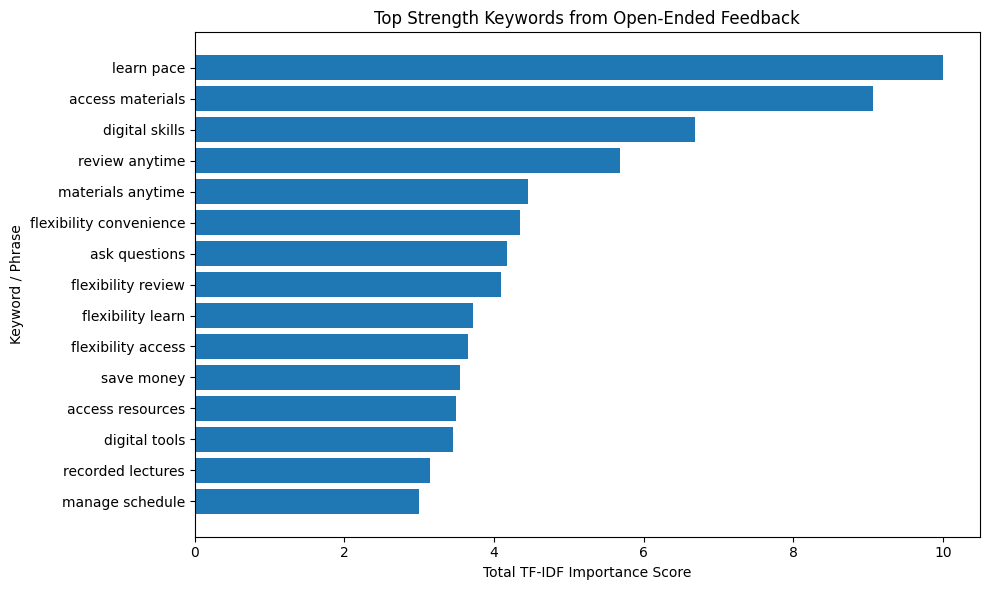

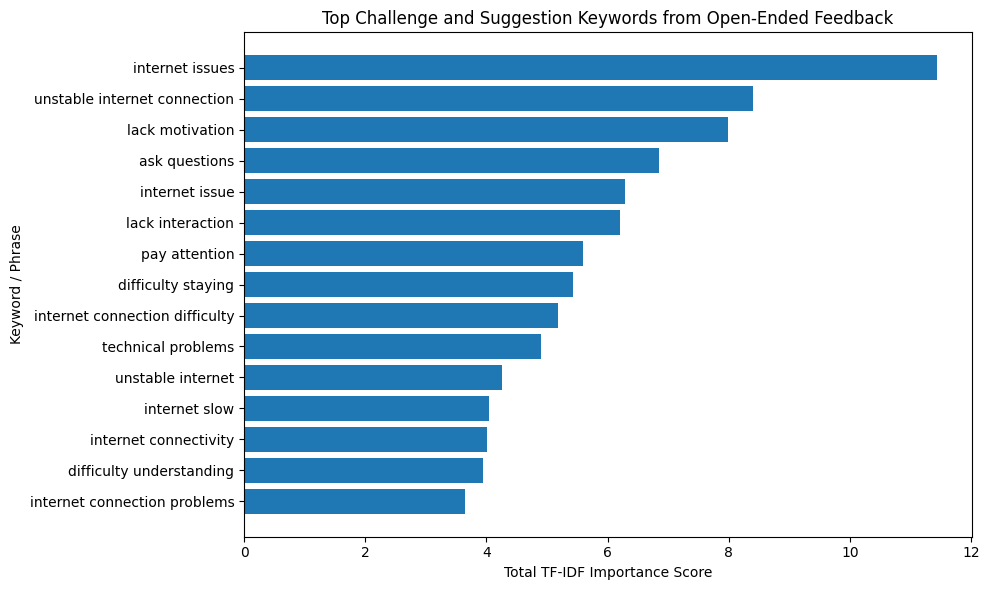

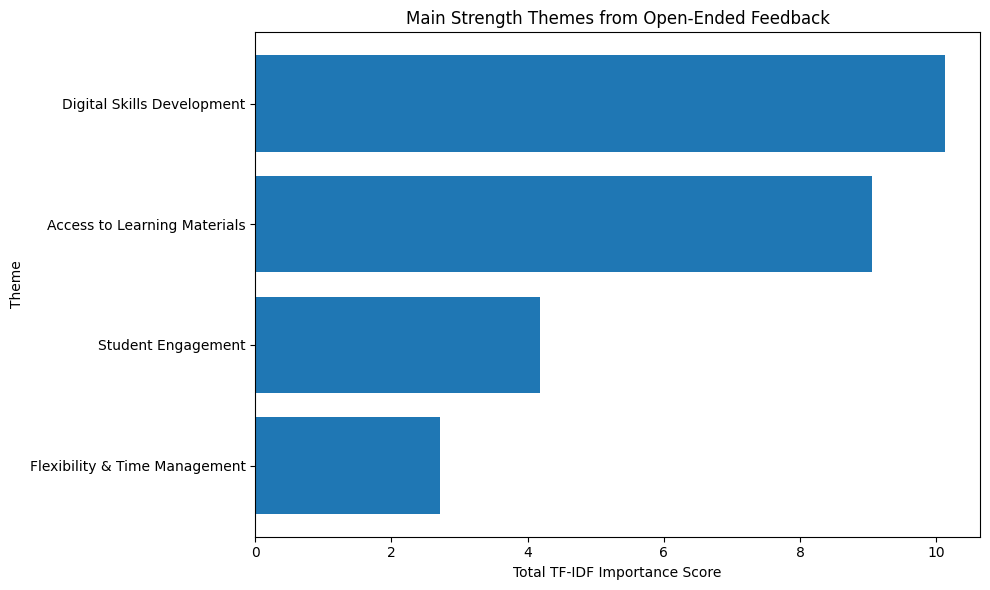

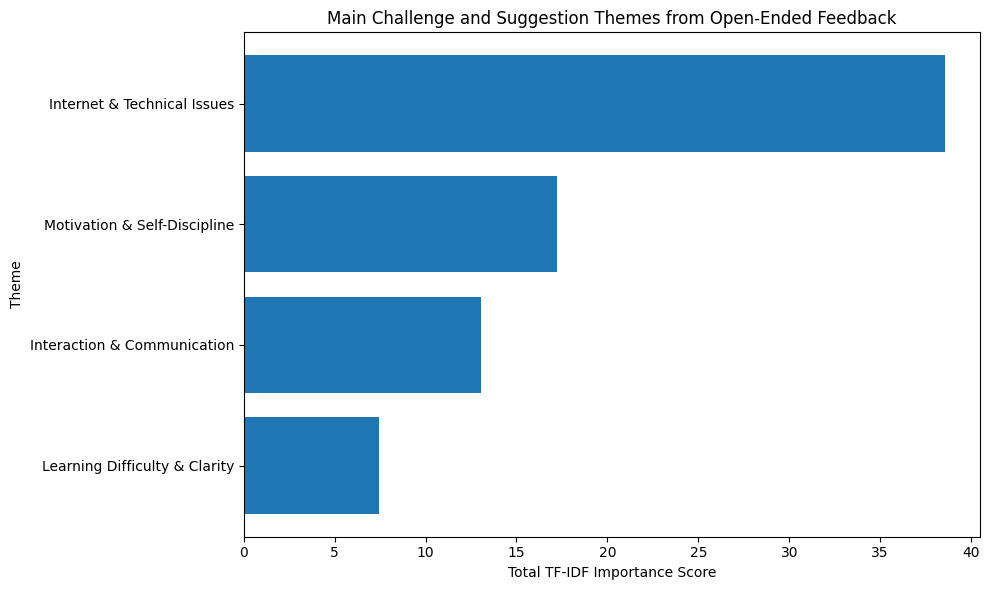

In [16]:
def plot_top_keywords(keyword_df, title, top_n=None):
    top_n = top_n or visual_cfg["keyword_top_n"]
    if keyword_df.empty:
        print(f"No keyword data available for: {title}")
        return
    plot_df = keyword_df.sort_values("tfidf_score", ascending=False).head(top_n).sort_values("tfidf_score", ascending=True)
    plt.figure(figsize=tuple(visual_cfg["keyword_figsize"]))
    plt.barh(plot_df["keyword"], plot_df["tfidf_score"])
    plt.xlabel("Total TF-IDF Importance Score")
    plt.ylabel("Keyword / Phrase")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_theme_summary(theme_summary, title):
    if theme_summary.empty:
        print(f"No theme data available for: {title}")
        return
    plot_df = theme_summary.sort_values("total_score", ascending=True)
    plt.figure(figsize=tuple(visual_cfg["theme_figsize"]))
    plt.barh(plot_df["theme"], plot_df["total_score"])
    plt.xlabel("Total TF-IDF Importance Score")
    plt.ylabel("Theme")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_top_keywords(strengths_keywords, visual_cfg["titles"]["strength_keywords"])
plot_top_keywords(challenges_keywords, visual_cfg["titles"]["challenge_keywords"])
plot_theme_summary(strength_theme_summary, visual_cfg["titles"]["strength_themes"])
plot_theme_summary(challenge_theme_summary, visual_cfg["titles"]["challenge_themes"])

## Tie themes with learner segments

In [9]:
def build_cluster_theme_summary(df, cluster_col, cluster_label_col, text_col, theme_map, top_n_keywords=None):
    top_n_keywords = top_n_keywords or tfidf_cfg["cluster_theme_top_n_keywords"]
    min_students = nlp_cfg["cluster_analysis"]["min_students_per_cluster"]
    all_rows = []

    for cluster in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cluster]
        if subset.shape[0] < min_students:
            continue
        cluster_label = subset[cluster_label_col].iloc[0] if cluster_label_col in subset.columns else str(cluster)
        keyword_df = get_top_tfidf_keywords(subset, text_col, top_n=top_n_keywords)
        theme_summary = build_theme_summary(keyword_df, theme_map)
        for _, row in theme_summary.iterrows():
            all_rows.append({"cluster": cluster, "cluster_label": cluster_label, "theme": row["theme"], "keywords": row["keywords"], "total_score": row["total_score"], "keyword_count": row["keyword_count"], "n_students": subset.shape[0]})

    return pd.DataFrame(all_rows)


cluster_strength_themes = build_cluster_theme_summary(df, cluster_col, cluster_label_col, text_cols["strength_clean"], strength_theme_map)
cluster_challenge_themes = build_cluster_theme_summary(df, cluster_col, cluster_label_col, text_cols["challenge_clean"], challenge_theme_map)

display(cluster_strength_themes)
display(cluster_challenge_themes)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Moderately Engaged (Passive) Learners,Digital Skills Development,"digital skills, digital skill",5.461730,2,252
1,1,Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,2.874224,1,252
2,1,Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.477420,1,252
3,1,Moderately Engaged (Passive) Learners,Student Engagement,ask questions,1.454788,1,252
4,2,Highly Engaged (Active) Learners,Access to Learning Materials,"access materials, recorded videos",8.802329,2,318
5,2,Highly Engaged (Active) Learners,Digital Skills Development,"digital skills, digital tools",7.334670,2,318
6,2,Highly Engaged (Active) Learners,Student Engagement,ask questions,2.851600,1,318
7,2,Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,318


,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, technical problems, internet ...",25.366110,8,252
1,1,Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, pay attention",7.986156,2,252
2,1,Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, limited interaction",5.747348,2,252
3,1,Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,"unclear instructions, difficulty understanding",3.819570,2,252
4,2,Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet issue, internet prob...",20.130922,7,318
5,2,Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, lack interaction, interactive a...",12.654784,4,318
6,2,Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack discipline, lack motivation",10.025026,3,318
7,2,Highly Engaged (Active) Learners,Learning Difficulty & Clarity,difficulty understanding,3.151339,1,318


In [10]:
sort_cols = nlp_cfg["cluster_analysis"]["sort_columns"]
sort_ascending = nlp_cfg["cluster_analysis"]["sort_ascending"]

if not cluster_strength_themes.empty:
    display(cluster_strength_themes.sort_values(sort_cols, ascending=sort_ascending))
if not cluster_challenge_themes.empty:
    display(cluster_challenge_themes.sort_values(sort_cols, ascending=sort_ascending))

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Moderately Engaged (Passive) Learners,Digital Skills Development,"digital skills, digital skill",5.461730,2,252
1,1,Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,2.874224,1,252
2,1,Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.477420,1,252
3,1,Moderately Engaged (Passive) Learners,Student Engagement,ask questions,1.454788,1,252
4,2,Highly Engaged (Active) Learners,Access to Learning Materials,"access materials, recorded videos",8.802329,2,318
5,2,Highly Engaged (Active) Learners,Digital Skills Development,"digital skills, digital tools",7.334670,2,318
6,2,Highly Engaged (Active) Learners,Student Engagement,ask questions,2.851600,1,318
7,2,Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,318


,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, technical problems, internet ...",25.366110,8,252
1,1,Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, pay attention",7.986156,2,252
2,1,Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, limited interaction",5.747348,2,252
3,1,Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,"unclear instructions, difficulty understanding",3.819570,2,252
4,2,Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet issue, internet prob...",20.130922,7,318
5,2,Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, lack interaction, interactive a...",12.654784,4,318
6,2,Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack discipline, lack motivation",10.025026,3,318
7,2,Highly Engaged (Active) Learners,Learning Difficulty & Clarity,difficulty understanding,3.151339,1,318


## Dynamic interpretation guide

Use the displayed cluster theme tables above to write the thesis interpretation. Avoid hardcoding scores in markdown because theme scores change when the dataset, translation output, or keyword map changes. The safest interpretation pattern is:

```text
Learner segment → strongest strength themes → strongest challenge themes → recommendation needs
```

In [11]:
def build_cluster_keyword_summary(df, cluster_col, cluster_label_col, text_col, top_n_keywords=None, ngram_range=None):
    top_n_keywords = top_n_keywords or tfidf_cfg["cluster_keyword_top_n_keywords"]
    ngram_range = tuple(ngram_range or tfidf_cfg["ngram_range"])
    min_students = nlp_cfg["cluster_analysis"]["min_students_per_cluster"]
    all_rows = []

    for cluster in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cluster]
        if subset.shape[0] < min_students:
            continue
        cluster_label = subset[cluster_label_col].iloc[0] if cluster_label_col in subset.columns else str(cluster)
        keyword_df = get_top_tfidf_keywords(subset, text_col, top_n=top_n_keywords, ngram_range=ngram_range)
        for _, row in keyword_df.iterrows():
            all_rows.append({"cluster": cluster, "cluster_label": cluster_label, "keyword": row["keyword"], "tfidf_score": row["tfidf_score"], "n_students": subset.shape[0], "response_type": text_col})
    return pd.DataFrame(all_rows)


cluster_strength_keywords = build_cluster_keyword_summary(df, cluster_col, cluster_label_col, text_cols["strength_clean"])
cluster_challenge_keywords = build_cluster_keyword_summary(df, cluster_col, cluster_label_col, text_cols["challenge_clean"])

display(cluster_strength_keywords)
display(cluster_challenge_keywords)

,cluster,cluster_label,keyword,tfidf_score,n_students,response_type
0,1,Moderately Engaged (Passive) Learners,learn pace,7.299270,252,open_strengths_clean
1,1,Moderately Engaged (Passive) Learners,digital skills,3.461730,252,open_strengths_clean
2,1,Moderately Engaged (Passive) Learners,save money,3.000000,252,open_strengths_clean
3,1,Moderately Engaged (Passive) Learners,access materials,2.874224,252,open_strengths_clean
4,1,Moderately Engaged (Passive) Learners,flexibility review,2.657681,252,open_strengths_clean
5,1,Moderately Engaged (Passive) Learners,review anytime,2.395251,252,open_strengths_clean
6,1,Moderately Engaged (Passive) Learners,in person interaction,2.258315,252,open_strengths_clean
7,1,Moderately Engaged (Passive) Learners,flexibility learn,2.219958,252,open_strengths_clean
8,1,Moderately Engaged (Passive) Learners,digital skill,2.000000,252,open_strengths_clean
9,1,Moderately Engaged (Passive) Learners,missed review,2.000000,252,open_strengths_clean


,cluster,cluster_label,keyword,tfidf_score,n_students,response_type
0,1,Moderately Engaged (Passive) Learners,lack motivation,6.378849,252,open_challenges_clean
1,1,Moderately Engaged (Passive) Learners,internet issues,5.665146,252,open_challenges_clean
2,1,Moderately Engaged (Passive) Learners,lack interaction,4.248314,252,open_challenges_clean
3,1,Moderately Engaged (Passive) Learners,unstable internet connection,4.138255,252,open_challenges_clean
4,1,Moderately Engaged (Passive) Learners,technical problems,3.756267,252,open_challenges_clean
5,1,Moderately Engaged (Passive) Learners,internet issue,3.671251,252,open_challenges_clean
6,1,Moderately Engaged (Passive) Learners,internet connectivity,3.409783,252,open_challenges_clean
7,1,Moderately Engaged (Passive) Learners,unstable internet,3.055950,252,open_challenges_clean
8,1,Moderately Engaged (Passive) Learners,internet connection lack,2.888988,252,open_challenges_clean
9,1,Moderately Engaged (Passive) Learners,unclear instructions,2.349803,252,open_challenges_clean


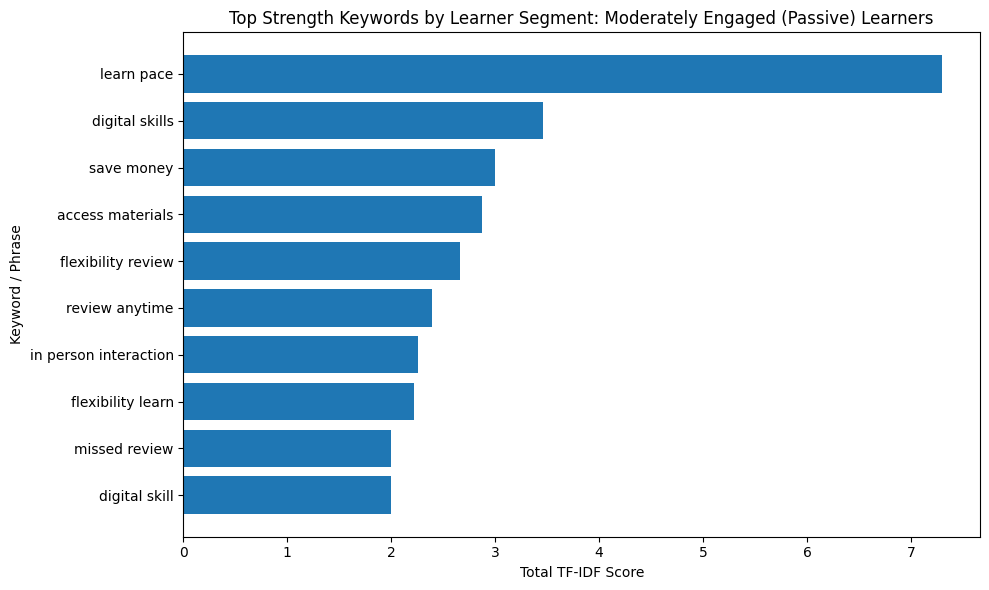

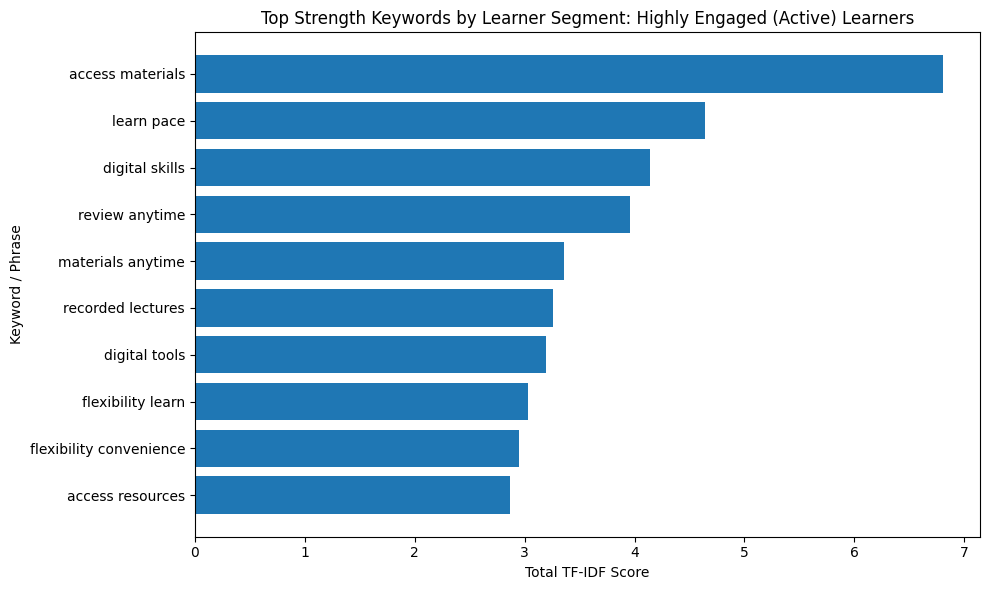

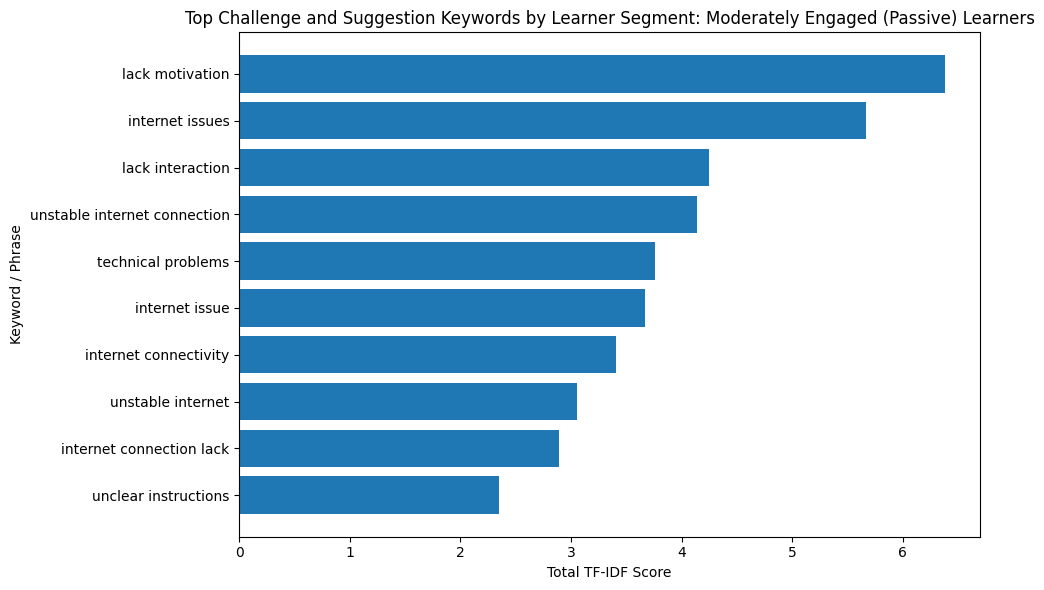

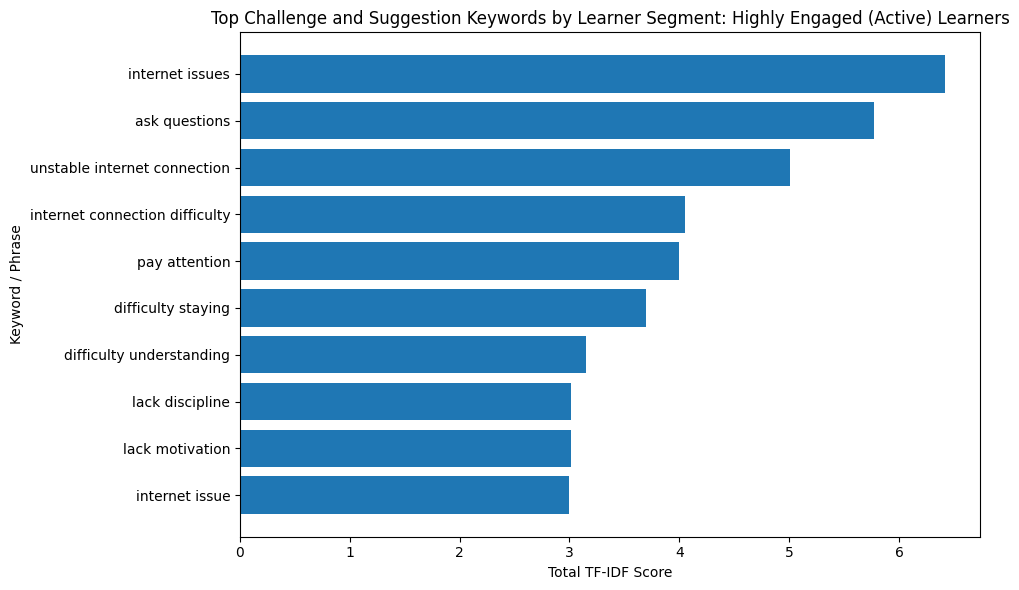

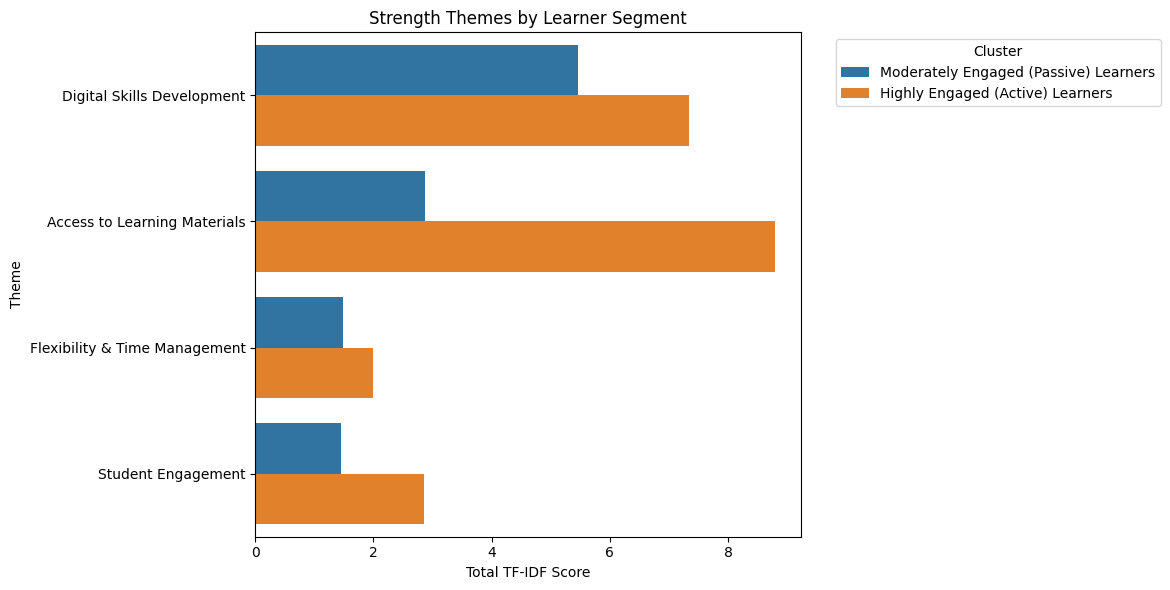

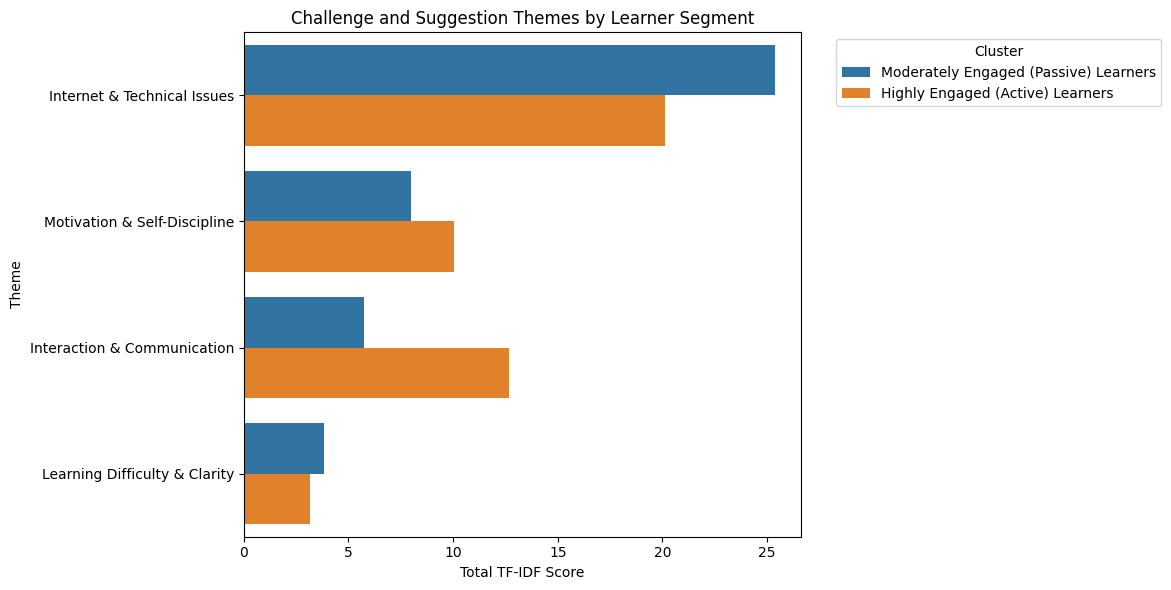

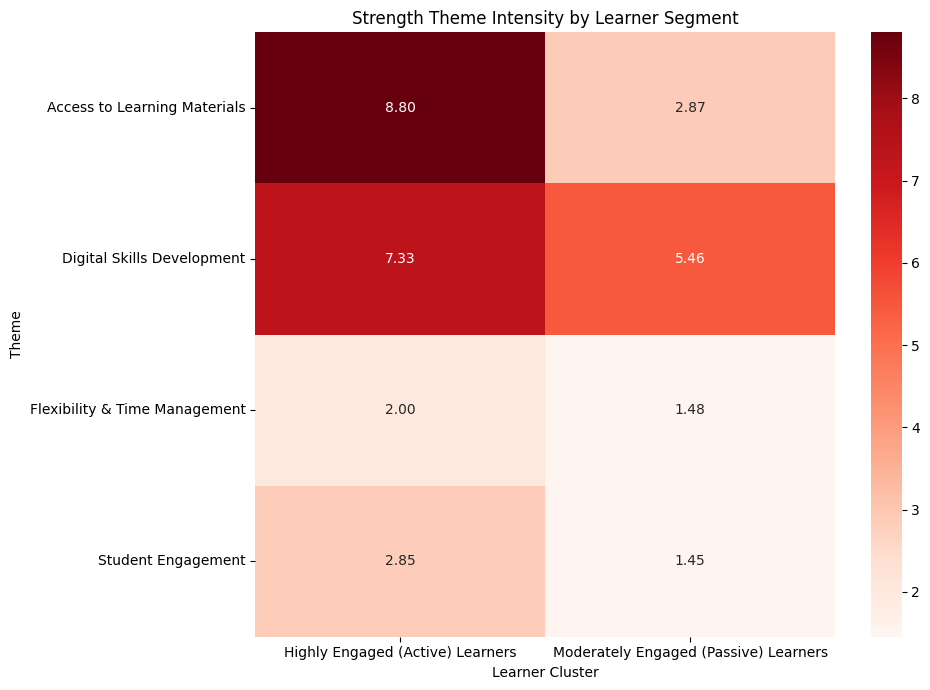

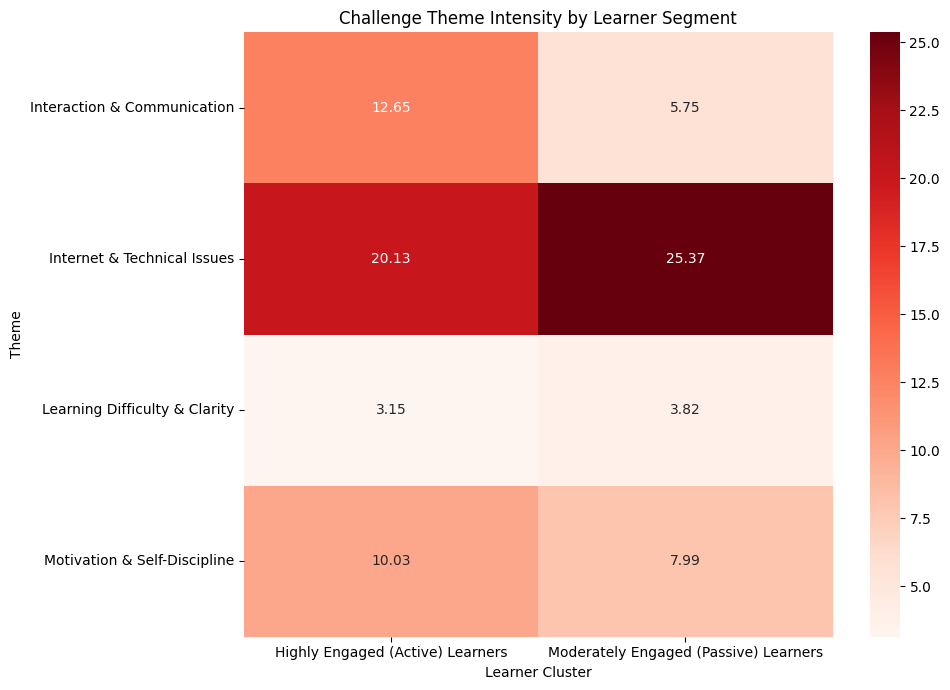

In [12]:
def plot_keywords_by_cluster(cluster_keyword_df, title, top_n=None):
    top_n = top_n or visual_cfg["cluster_keyword_top_n"]
    if cluster_keyword_df.empty:
        print(f"No keyword data available for: {title}")
        return
    for cluster_label in cluster_keyword_df["cluster_label"].dropna().unique():
        plot_df = cluster_keyword_df[cluster_keyword_df["cluster_label"] == cluster_label].sort_values("tfidf_score", ascending=False).head(top_n).sort_values("tfidf_score", ascending=True)
        plt.figure(figsize=tuple(visual_cfg["keyword_figsize"]))
        plt.barh(plot_df["keyword"], plot_df["tfidf_score"])
        plt.xlabel("Total TF-IDF Score")
        plt.ylabel("Keyword / Phrase")
        plt.title(f"{title}: {cluster_label}")
        plt.tight_layout()
        plt.show()


def plot_themes_by_cluster(cluster_theme_df, title, top_n=None):
    top_n = top_n or visual_cfg["cluster_theme_top_n"]
    if cluster_theme_df.empty:
        print(f"No cluster theme data available for: {title}")
        return
    top_themes = cluster_theme_df.groupby("theme")["total_score"].sum().sort_values(ascending=False).head(top_n).index
    plot_df = cluster_theme_df[cluster_theme_df["theme"].isin(top_themes)]
    plt.figure(figsize=tuple(visual_cfg["cluster_theme_figsize"]))
    sns.barplot(data=plot_df, x="total_score", y="theme", hue="cluster_label")
    plt.xlabel("Total TF-IDF Score")
    plt.ylabel("Theme")
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_theme_cluster_heatmap(cluster_theme_df, title):
    if cluster_theme_df.empty:
        print(f"No cluster theme data available for: {title}")
        return
    heatmap_df = cluster_theme_df.pivot_table(index="theme", columns="cluster_label", values="total_score", aggfunc="sum", fill_value=0)
    plt.figure(figsize=tuple(visual_cfg["heatmap_figsize"]))
    sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap=visual_cfg["heatmap_cmap"])
    plt.xlabel("Learner Cluster")
    plt.ylabel("Theme")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_keywords_by_cluster(cluster_strength_keywords, visual_cfg["titles"]["cluster_strength_keywords"])
plot_keywords_by_cluster(cluster_challenge_keywords, visual_cfg["titles"]["cluster_challenge_keywords"])
plot_themes_by_cluster(cluster_strength_themes, visual_cfg["titles"]["cluster_strength_themes"])
plot_themes_by_cluster(cluster_challenge_themes, visual_cfg["titles"]["cluster_challenge_themes"])
plot_theme_cluster_heatmap(cluster_strength_themes, visual_cfg["titles"]["cluster_strength_heatmap"])
plot_theme_cluster_heatmap(cluster_challenge_themes, visual_cfg["titles"]["cluster_challenge_heatmap"])

## Export student-level recommendation features

In [13]:
# STUDENT-LEVEL THEME AND RECOMMENDATION TAGS

non_meaningful_set = {normalize_text_for_matching(x) for x in tagging_cfg["non_meaningful_responses"]}

df["strength_themes"] = df[text_cols["strength_clean"]].apply(lambda x: detect_themes(x, strength_theme_map, non_meaningful_set))
df["challenge_themes"] = df[text_cols["challenge_clean"]].apply(lambda x: detect_themes(x, challenge_theme_map, non_meaningful_set))
df["strength_tags"] = df["strength_themes"].apply(lambda themes: themes_to_tags(themes, theme_to_recommendation_map))
df["challenge_tags"] = df["challenge_themes"].apply(lambda themes: themes_to_tags(themes, theme_to_recommendation_map))
df["recommendation_tags"] = df.apply(lambda row: sorted(set(row["strength_tags"] + row["challenge_tags"])), axis=1)
df["segment_default_tags"] = df[cluster_label_col].apply(lambda label: get_segment_default_tags(label, tagging_cfg["segment_default_tags"]))
df["final_recommendation_tags"] = df.apply(
    lambda row: create_final_recommendation_tags(
        row["recommendation_tags"],
        row["segment_default_tags"],
        use_fallback=tagging_cfg.get("use_segment_fallback_when_nlp_tags_empty", True),
    ),
    axis=1,
)
df["rule_based_recommendations"] = df["final_recommendation_tags"].apply(
    lambda tags: build_rule_based_recommendations(tags, nlp_cfg["recommendation_rule_bank"])
)


In [14]:
# CONVERT LIST/DICT COLUMNS TO JSON STRINGS AND EXPORT

ensure_ascii = nlp_cfg.get("json_serialisation", {}).get("ensure_ascii", False)
json_cols = nlp_cfg["columns"]["json_columns"]
for col in json_cols:
    df[col] = df[col].apply(lambda x: json.dumps(x, ensure_ascii=ensure_ascii))

export_cols = [col for col in nlp_cfg["columns"]["export_columns"] if col in df.columns]
student_recommendation_features = df[export_cols].copy()

output_path = resolve_project_path(nlp_cfg["io"]["output_path"])
output_path.parent.mkdir(parents=True, exist_ok=True)
write_options = nlp_cfg["io"].get("write_csv_options", {})
student_recommendation_features.to_csv(output_path, **write_options)

print("Student recommendation feature dataset exported successfully.")
print(f"Saved to: {output_path}")
print(f"Shape: {student_recommendation_features.shape}")
display(student_recommendation_features.head(nlp_cfg.get("display", {}).get("preview_rows", 10)))

Student recommendation feature dataset exported successfully.
Saved to: C:\Users\Tepy\Documents\tepy\Final Internship Docs\Blended-Learning\ml\data\processed\student_recommendation_features.csv
Shape: (570, 13)


,student_id,student_segment,student_segment_label,open_strengths_en,open_challenges_suggestions_en,strength_themes,challenge_themes,strength_tags,challenge_tags,recommendation_tags,segment_default_tags,final_recommendation_tags,rule_based_recommendations
0,e20210686,1,Moderately Engaged (Passive) Learners,Nothing,Nothing,[],[],[],[],[],"[""interaction"", ""learning_support"", ""motivatio...","[""interaction"", ""learning_support"", ""motivatio...","[{""tag"": ""interaction"", ""title"": ""Increase int..."
1,e20241146,2,Highly Engaged (Active) Learners,"Very good, excellent","No big challenge, i’m the best","[""Learning Convenience & Effectiveness""]",[],"[""learning_effectiveness""]",[],"[""learning_effectiveness""]","[""content_access"", ""digital_skill"", ""engagemen...","[""learning_effectiveness""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
2,e20240609,2,Highly Engaged (Active) Learners,Will try hard,Lack of self-discipline,[],"[""Motivation & Self-Discipline""]",[],"[""motivation""]","[""motivation""]","[""content_access"", ""digital_skill"", ""engagemen...","[""motivation""]","[{""tag"": ""motivation"", ""title"": ""Support motiv..."
3,e20240542,1,Moderately Engaged (Passive) Learners,getting more experience,Discipline on daily studying,"[""Learning Convenience & Effectiveness""]","[""Motivation & Self-Discipline""]","[""learning_effectiveness""]","[""motivation""]","[""learning_effectiveness"", ""motivation""]","[""interaction"", ""learning_support"", ""motivatio...","[""learning_effectiveness"", ""motivation""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
4,e20220287,1,Moderately Engaged (Passive) Learners,Student could retrieve the lesson once they wa...,Add Ai assistance,"[""Access to Learning Materials""]",[],"[""content_access""]",[],"[""content_access""]","[""interaction"", ""learning_support"", ""motivatio...","[""content_access""]","[{""tag"": ""content_access"", ""title"": ""Strengthe..."
5,e20210180,1,Moderately Engaged (Passive) Learners,Innovate yourself with the technology world,Lack of resources and misinformation,"[""Digital Skills Development""]","[""Learning Resources & Environment""]","[""digital_skill""]","[""learning_environment""]","[""digital_skill"", ""learning_environment""]","[""interaction"", ""learning_support"", ""motivatio...","[""digital_skill"", ""learning_environment""]","[{""tag"": ""digital_skill"", ""title"": ""Develop di..."
6,e20241245,1,Moderately Engaged (Passive) Learners,Blended learning has many positive aspects. It...,The biggest challenges of blended learning are...,"[""Access to Learning Materials"", ""Digital Skil...","[""Interaction & Communication"", ""Internet & Te...","[""content_access"", ""digital_skill"", ""engagemen...","[""interaction"", ""learning_environment"", ""learn...","[""content_access"", ""digital_skill"", ""engagemen...","[""interaction"", ""learning_support"", ""motivatio...","[""content_access"", ""digital_skill"", ""engagemen...","[{""tag"": ""content_access"", ""title"": ""Strengthe..."
7,e20221090,2,Highly Engaged (Active) Learners,Give a chance for students who prefer both onl...,"Internet issues, technical problems, lack of i...","[""Flexibility & Time Management""]","[""Interaction & Communication"", ""Internet & Te...","[""self_paced""]","[""interaction"", ""tech_issue""]","[""interaction"", ""self_paced"", ""tech_issue""]","[""content_access"", ""digital_skill"", ""engagemen...","[""interaction"", ""self_paced"", ""tech_issue""]","[{""tag"": ""interaction"", ""title"": ""Increase int..."
8,e20250089,1,Moderately Engaged (Passive) Learners,Give me time to do my stuff,Probably the internet connection,[],"[""Internet & Technical Issues""]",[],"[""tech_issue""]","[""tech_issue""]","[""interaction"", ""learning_support"", ""motivatio...","[""tech_issue""]","[{""tag"": ""tech_issue"", ""title"": ""Improve techn..."
9,e20240950,2,Highly Engaged (Active) Learners,Agree,Agree,[],[],[],[],[],"[""content_access"", ""digital_s

In [15]:
def json_len(x):
    try:
        return len(json.loads(x))
    except Exception:
        return 0


print("Total students:", len(student_recommendation_features))
print("Empty NLP recommendation_tags:", student_recommendation_features["recommendation_tags"].apply(json_len).eq(0).sum())
print("Empty final_recommendation_tags:", student_recommendation_features["final_recommendation_tags"].apply(json_len).eq(0).sum())

Total students: 570
Empty NLP recommendation_tags: 60
Empty final_recommendation_tags: 0
